## Figure 6,7,8 (parameter exploration) from formation channel paper 

below is the code that reproduces the 2D parameter exploration (simulation silos) exploration 


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 
from typing import Optional  # change Optional[str] to str | None when using higher versions of python3

In [2]:
## data path
path_to_github_folder = "/Users/floorbroekgaarden/Projects/GitHub/"
path_to_file_folder = "Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"
path_to_file = path_to_github_folder + path_to_file_folder


### Instructions 

for this code to work you will need the following files 
  - `DCOlabel + "_rates_review.csv"` For DCOlabel in BH-BH, BH-NS, and NS-NS  
 you can find this in the Zenodo file or on GitHub inside the Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/ folder 
  - it imports some functions from the `common_code` file above, but you dont need this :) (just uncomment if needed) 
  - likely you want to change the `save_path` in the code call below 
  

# BBHs, BHNS, and BNS; with SFRD model variations 




In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import math
from matplotlib.ticker import AutoMinorLocator
import re
%matplotlib inline




## note that this has a duplicate in Figure 3 function, make sure to update both (or in the future, have this file seperate and import it)
def obtain_fc_dict():
    """
    Returns a dictionary defining formation channel (fc) specifications.

    Each top-level key corresponds to a grouping of formation channels 
    (e.g., 'CE_simple', 'CE_detailed', or 'total').  
    Each group contains either a list of 'channels' (with properties) 
    or a single entry (for 'total').
    """


    palette = {
        # Neutrals
        "gray_light":  "#e0e0e0",
        "gray_dark":   "#C2C2C2",

        # Non-CE warm family
        "orange_main": "#FFA630",
        "orange_sub":  "#ffc857",
        "orange_soft": "#f4a259",
        "red_soft":    "#e45756",
        "rose":        "#d96c75",
        "terracotta":  "#bc4b51",
        "peach":       "#ffb5a7",

        # CE cool family
        "blue_main":   "#00A7E1",
        "blue_light":  "#5dade2",
        "blue_mid":    "#0474BA",
        "blue_dark":   "#004e89",
        "indigo":      "#3a3d98",   # new deep indigo for AIC
        "teal_light":  "#20b2aa",
        "green_blue":  "#58AD8B",
        "aqua":        "#00bfc4",
        "seafoam":     "#8dd3c7",
        "mint":        "#9de0ad",
    }


    fc_dict = {
        # A simplified common-envelope grouping (just two channels).
        "CE_simple": {
            "channels": [
                {"name": "fraction without common envelope", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope', "axlabel":"fraction without CE"},
                {"name": "fraction with common envelope",    "color":palette["blue_main"],   "hatch": '//' , "label":'with common envelope', "axlabel":"fraction with CE"},
                {"name": "fraction not specified",           "color":palette[ "gray_dark"],  "hatch":None,   "label":'not specified'}
            ],
            "label_ncols":3
        },

        
        "CE_detailed": {
            "channels": [
                
                # --- Non-CE channels (warm hues, all unique) ---
                {"name": "without CE (no detail specified)", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope'},
                {"name": "SMT before and after channel",     "color":palette["red_soft"],    "hatch": '...', "label":'classic only stable'},
                {"name": "SMT+NON",                          "color":palette["rose"],        "hatch": '...', "label":'SMT + NON'},
                {"name": "NON+SMT",                          "color":palette["orange_soft"], "hatch": '...', "label":'NON+SMT'},
                {"name": "NON + NON",                        "color":palette["terracotta"],  "hatch": '...', "label":'NON+NON'},
                {"name": "channel V intrinsic (z=0) other without CE", "color":palette["peach"], "hatch": 'ooo', "label":'other without CE'},
                {"name": "CHE",                              "color":palette["orange_sub"],     "hatch":'...',   "label":'CHE (no MT)'},
                # --- CE channels (cool hues, all unique) ---
                {"name": "with CE (no detail specified)",                 "color":palette["blue_main"],  "hatch": "\\", "label":'with common envelope'},
                
                {"name": "channel I intrinsic (z=0) classic CE (SMT+CE)", "color":palette["blue_light"], "hatch": "//", "label":'classic CE'},
                {"name": "channel III intrinsic (z=0) SCCE",              "color":palette["blue_mid"],   "hatch": "\\", "label":'single-core CE'},
                {"name": "channel IV intrinsic (z=0) DCCE",               "color":palette["teal_light"], "hatch": '//', "label":'double-core CE'},
                
                {"name": "CEE + SMT",                                     "color":palette["green_blue"], "hatch": '//', "label":'CEE + SMT'},
                {"name": "CEE+CEE",                                       "color":palette["aqua"],       "hatch": "\\", "label":'CEE+CEE'},
                {"name": "NON+CEE",                                       "color":palette["seafoam"],    "hatch": '//', "label":'NON+CEE'},
                {"name": "CEE+NON",                                       "color":palette["mint"],       "hatch": '//', "label":'CEE+NON'},

                {"name": "channel radCEE",  "color":palette["blue_dark"], "hatch": '\\', "label":'radiative CE'},
                {"name": "channel convCEE", "color":palette["teal_light"], "hatch": '//', "label":'convective CE'},
                {"name": "channel V intrinsic (z=0) other with CE", "color":palette["seafoam"], "hatch": "\\", "label":'other with CE'},
                {"name": "channel AIC with CE", "color":palette["indigo"], "hatch": '//', "label":'AIC with CE'},


                {"name": "channel V intrinsic (z=0) CE not specified",    "color":palette["gray_dark"],  "hatch": None, "label":'other CE not specified'},
            ],
            "label_ncols":5
        },

        # A total merger rate across all intrinsic channels.
        "total": {
            "name": "All intrinsic (z=0) [Gpc^-3 yr^-1]",
            "color": "black",
            "hatch": None,
            "label":r"All intrinsic ($z\sim0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]",
            "label_ncols":1,
            "axlabel":r"$\mathcal{R}_{\rm{m}}$ \  $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]"
#             "axlabel":r"Total local merger rate", # % ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]
        },
    }

    return fc_dict


mpl.rcParams['hatch.linewidth'] = 0.5   # default is 1.0
mpl.rcParams['hatch.color'] = 'darkslategray'   # optional: set hatch color







def plot_withoutCE_all_and_by_study(
    path_to_file,
    DCOlabel="BH-BH",
    broek_sfrd_path=None,
    relation_file=None,
    marker="o",
    size=50,
    line_alpha=0.7,
    line_style="-",
    line_width=2.5,
    figsize_all=(8, 6),
    ncols_grid=5,
    figsize_grid_per_panel=(4.0, 3.2),  # (width, height) per subplot
    cmap_name="tab20",
    sharex=True,
    sharey=True,
    save_big_pdf=None,
    save_grid_pdf=None,
    dpi=300,
):
    """
    Make:
      (1) one big plot: fraction without CE vs total intrinsic rate for all studies
      (2) a subplot grid: same relation, one panel per study (legend)

    Returns
    -------
    fig_all, ax_all, fig_grid, axes_grid
    """
    
    def map_dco_label_for_broek_file(dco_label: str) -> str:
        """
        Map plotting labels like 'BH-BH' to file labels like 'BHBH'.
        """
        mapping = {
            "BH-BH": "BHBH",
            "BH-NS": "BHNS",
            "NS-NS": "NSNS",
            "BHBH": "BHBH",
            "BHNS": "BHNS",
            "NSNS": "NSNS",
        }
        if dco_label not in mapping:
            raise ValueError(f"Unsupported DCOlabel: {dco_label}")
        return mapping[dco_label]
    

    # --- Load relation file (pairs of models) ---
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # --- Load rates file (fractions + total rate per model) ---
    rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
    df_rates = df_rates.fillna(0.0).set_index("model")

    # --- OPTIONAL: load van Son 2023 secondary SFRD variations ---
    vanson_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(vanson_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(vanson_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None
    
    # --- OPTIONAL: load Broekgaarden secondary SFRD/S(Z,z) variations ---
    broek_file_label = map_dco_label_for_broek_file(DCOlabel)

    if broek_sfrd_path is None:
        broek_sfrd_file = os.path.join(
            path_to_file,
            "extra_fc_rates",
            f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
        )
    else:
        # allow either a direct file path OR a folder path
        if os.path.isdir(broek_sfrd_path):
            broek_sfrd_file = os.path.join(
                broek_sfrd_path,
                f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
            )
        else:
            broek_sfrd_file = broek_sfrd_path

    print("Looking for Broekgaarden SFRD file at:", broek_sfrd_file)
    print("Exists?", os.path.exists(broek_sfrd_file))

    if os.path.exists(broek_sfrd_file):
        df_rates_broek_sfrd = pd.read_csv(broek_sfrd_file).fillna(0.0)
        print("Loaded Broekgaarden SFRD rows:", len(df_rates_broek_sfrd))
        print("Columns:", list(df_rates_broek_sfrd.columns))
    else:
        df_rates_broek_sfrd = None
        print("Broekgaarden SFRD file not loaded.")
        
        
        
        
        
    

    # --- Formation-channel metadata ---
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = fc_dict["total"]["axlabel"]             # y-axis label (rate)

    # x axis label for "fraction without common envelope"
    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    # --- Studies (legend groups) ---
    legends = list(df_rel["legend"].dropna().unique())
    legends_sorted = sorted(legends)

    # --- Color map ---
    if cmap_name.lower() == "husl":
        palette = sns.color_palette("husl", len(legends_sorted))
    else:
        cmap = plt.get_cmap(cmap_name)
        palette = [cmap(i / max(1, len(legends_sorted)-1)) for i in range(len(legends_sorted))]

    color_map = {leg: palette[i] for i, leg in enumerate(legends_sorted)}

    # --- explicitly set van Son 2023 study + fiducial model ---
    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "
    # --- explicitly set Broekgaarden study label ---
    broek_legend = None
    for leg in legends_sorted:
        leg_clean = str(leg).strip().lower()
        if "broekgaarden" in leg_clean:
            broek_legend = leg
            break

    print("Using broek_legend =", repr(broek_legend))

    print("Using vanSon_legend =", repr(vanSon_legend))
    print("Using vanSon_fiducial_model =", repr(vanSon_fiducial_model))
    print("Using broek_legend =", repr(broek_legend))
    
    
    

    # ------------- helper: plot a set of relations onto an axis -------------
    def plot_relations_on_ax(ax, df_rel_subset, legend_for_color=None):
        """
        Plot points for models and connect from->to for each row in df_rel_subset.
        If legend_for_color is None, color per row's legend.
        """
        for _, row in df_rel_subset.iterrows():
            leg = row["legend"]
            color = color_map[legend_for_color] if legend_for_color is not None else color_map.get(leg, "k")

            m_from = row["from_modelname"]
            m_to = row["to_modelname"]

            coords = {}
            for model in [m_from, m_to]:
                if model not in df_rates.index:
                    continue

                x = df_rates.loc[model, "fraction without common envelope"]
                y = df_rates.loc[model, fc_total_header]
                coords[model] = (x, y)

                ax.scatter(
                    x, y,
                    s=size,
                    c=[color],
                    marker=marker,
                    edgecolor="k",
                    linewidths=0.5,
                    zorder=10
                )

            if m_from in coords and m_to in coords:
                (x1, y1) = coords[m_from]
                (x2, y2) = coords[m_to]
                ax.plot(
                    [x1, x2], [y1, y2],
                    color=color,
                    linestyle=line_style,
                    linewidth=line_width,
                    alpha=line_alpha,
                    zorder=5
                )

    # ------------- helper: plot van Son 2023 secondary SFRD variations -------------
    def plot_vanSon2023_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for van Son 2023:
        - same color as van Son 2023
        - behind the main relations
        - each extra point connected to the fiducial main-model point
        """
        if df_rates_vanson_sfrd is None:
            return
        if legend_for_color is None:
            return
        if vanSon_fiducial_model is None:
            return
        if vanSon_fiducial_model not in df_rates.index:
            return
        if legend_for_color != vanSon_legend:
            return

        color = color_map[legend_for_color]

        # fiducial point from the MAIN rates file
        x_fid = df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"]
        y_fid = df_rates.loc[vanSon_fiducial_model, fc_total_header]

        # plot all extra points except any duplicate fiducial row in the extra csv
        for model in df_rates_vanson_sfrd.index:
            if "Fiducial" in str(model):
                continue

            x = df_rates_vanson_sfrd.loc[model, "fraction without common envelope"]
            y = df_rates_vanson_sfrd.loc[model, fc_total_header]

            # faint background line to fiducial
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.54,
                zorder=0
            )


            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )
    
    
    
    # ------------- helper: plot Broekgaarden secondary SFRD variations -------------
    def plot_broekgaarden_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for the Broekgaarden study:
        - same color as Broekgaarden study
        - behind the main relations
        - each extra point connected to the corresponding main-model point
          by matching model_name A/B/.../T to df_rates models like B22-A-fiducial
        """
        print("\n--- plot_broekgaarden_secondary_sfrd ---")
        print("legend_for_color =", repr(legend_for_color))
        print("broek_legend     =", repr(broek_legend))

        if df_rates_broek_sfrd is None:
            print("EXIT: df_rates_broek_sfrd is None")
            return
        if legend_for_color is None:
            print("EXIT: legend_for_color is None")
            return
        if broek_legend is None:
            print("EXIT: broek_legend is None")
            return
        if str(legend_for_color).strip() != str(broek_legend).strip():
            print("EXIT: legend mismatch")
            return
        if legend_for_color not in color_map:
            print("EXIT: legend_for_color not in color_map")
            return

        color = color_map[legend_for_color]

        # Build mapping letter -> main Broekgaarden fiducial model
        main_model_map = {}

        # First pass: explicitly prefer fiducial rows
        for letter in list("ABCDEFGHIJKLMNOPQRST"):
            fid_candidates = [
                str(model).strip()
                for model in df_rates.index
                if re.match(rf"^[A-Z0-9]+-{letter}-fiducial$", str(model).strip(), flags=re.IGNORECASE)
            ]
            if len(fid_candidates) > 0:
                main_model_map[letter] = fid_candidates[0]

        # Second pass: fallback to first B22-letter-* match if no fiducial exists
        for model in df_rates.index:
            model_str = str(model).strip()
            m = re.match(r"^[A-Z0-9]+-([A-T])-", model_str, flags=re.IGNORECASE)
            if m:
                letter = m.group(1).upper()
                if letter not in main_model_map:
                    main_model_map[letter] = model_str

#         print("Broekgaarden main_model_map:")
#         for k in sorted(main_model_map):
#             print(f"  {k} -> {main_model_map[k]}")

        n_plotted = 0

        for _, row in df_rates_broek_sfrd.iterrows():
            letter = str(row["model_name"]).strip().upper()

            if letter not in main_model_map:
                continue

            main_model = main_model_map[letter]

            # Main point from BH-BH_rates_review.csv
            x_fid = float(df_rates.loc[main_model, "fraction without common envelope"])
            y_fid = float(df_rates.loc[main_model, fc_total_header])

            # Background S(Z,z) variation point
            x = float(row["without_CE_fraction"])
            y = float(row["total_rate"])

            if not np.isfinite(x) or not np.isfinite(y):
                continue
            if y <= 0:
                continue

            # faint background line
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.34,
                zorder=0
            )

            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )

            n_plotted += 1

        print("Broekgaarden extra points plotted:", n_plotted)
    
    
    # ===================== (1) BIG PLOT: all studies =====================
    fig_all, ax_all = plt.subplots(1, 1, figsize=figsize_all)

    plot_relations_on_ax(ax_all, df_rel)

    # add van Son 2023 secondary SFRD variations in the background
#     if vanSon_legend is not None:
#         plot_vanSon2023_secondary_sfrd(ax_all, vanSon_legend)
        
#     # add Broekgaarden secondary SFRD variations in the background
#     if broek_legend is not None:
#         plot_broekgaarden_secondary_sfrd(ax_all, broek_legend)

    # axes styling
    layoutAxes(ax_all, nameX=xname, nameY=yname, fontsize=20)
    ax_all.set_xscale("linear")
    ax_all.set_yscale("log")
    ax_all.grid(True, alpha=0.3)
    ax_all.set_xlim(0,1)

    # legend (one handle per study)
    handles = []
    for leg in legends_sorted:
        handles.append(
            plt.Line2D([], [], color=color_map[leg], marker=marker, linestyle="",
                       markersize=2*np.sqrt(size)/2, markeredgecolor="k", label=leg)
        )
    ax_all.legend(handles=handles, loc="best", frameon=False, title=r"$\textbf{Study}$", ncol=2, fontsize=10)

    fig_all.tight_layout()

    # ===================== (2) GRID: one panel per study =====================
    n_studies = len(legends_sorted)
    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    fig_grid_w = figsize_grid_per_panel[0] * ncols
    fig_grid_h = figsize_grid_per_panel[1] * nrows
    fig_grid, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_grid_w, fig_grid_h),
        sharex=sharex,
        sharey=sharey
    )

    # Flatten axes robustly
    axes_flat = np.array(axes).reshape(-1)

    # --- style knobs (tweak to taste) ---
    tick_labelsize = 15
    tick_length_major = 5
    tick_length_minor = 3
    tick_width = 1.
    panel_labelsize = 10

    for i, leg in enumerate(legends_sorted):
        ax = axes_flat[i]
        df_sub = df_rel[df_rel["legend"] == leg]

        # plot this study
        plot_relations_on_ax(ax, df_sub, legend_for_color=leg)

        # add van Son 2023 secondary SFRD variations only in the van Son panel
        if str(leg).strip() == str(vanSon_legend).strip():
            plot_vanSon2023_secondary_sfrd(ax, vanSon_legend)
        
        # add Broekgaarden secondary SFRD variations only in the Broekgaarden panel
        if str(leg).strip() == str(broek_legend).strip():
            plot_broekgaarden_secondary_sfrd(ax, broek_legend)
        
        # scales/grid
        ax.set_xscale("linear")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)
        # ax.set_xlim(0,1)

        # --- put "model/study name" inside bottom-right of panel ---
        ax.text(
            0.98, 0.05, r'$\textbf{%s}$'%str(leg),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
                edgecolor="none"
            ),
            zorder=20
        )

        # --- ticks: bigger labels, shorter ticks, minor ticks on x ---
        ax.tick_params(
            axis="both", which="major",
            labelsize=tick_labelsize,
            length=tick_length_major,
            width=tick_width,
            direction="in"
        )
        ax.tick_params(
            axis="both", which="minor",
            labelsize=tick_labelsize,
            length=tick_length_minor,
            width=tick_width,
            direction="in"
        )

        # minor ticks on x-axis
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis="x", which="minor", bottom=True)

    # Turn off unused axes
    for j in range(n_studies, len(axes_flat)):
        axes_flat[j].axis("off")

    label_fontsize = 20
    ylabel_pad = 15

    if sharex:
        fig_grid.supxlabel(
            r'$\textbf{%s}$'%xname,
            fontsize=label_fontsize,
            y=0.02
        )

    if sharey:
        fig_grid.supylabel(
            r'$\textbf{%s}$'%yname,
            fontsize=label_fontsize,
            x=0.01
        )

    # --- remove spacing between subpanels ---
    fig_grid.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.995,
                             wspace=0.0, hspace=0.0)

    fig_grid.tight_layout()

    # ===================== SAVE FIGURES =====================
    if save_big_pdf is not None:
        fig_all.savefig(
            save_big_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved big plot to: {save_big_pdf}")

    if save_grid_pdf is not None:
        fig_grid.savefig(
            save_grid_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved grid plot to: {save_grid_pdf}")

    return fig_all, ax_all, fig_grid, axes

import os

import os

def make_withoutCE_plots(
    DCOlabel: str,
    base_plot_path: str = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    output_fig_path: str = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/",
    cmap_name: str = "husl",
    show: bool = True,
    ncols_grid=5
):
    """
    Wrapper to generate and save without-CE plots with consistent settings.
    """

    # ---------------- map label for filenames ----------------
    label_map = {
        "BH-BH": "BHBH",
        "BH-NS": "BHNS",
        "NS-NS": "NSNS",
        "BHBH": "BHBH",
        "BHNS": "BHNS",
        "NSNS": "NSNS",
    }

    if DCOlabel not in label_map:
        raise ValueError(f"Unsupported DCOlabel: {DCOlabel}")

    file_label = label_map[DCOlabel]

    # ---------------- paths ----------------
    data_path = base_plot_path

    # ensure output directory exists
    os.makedirs(output_fig_path, exist_ok=True)

    # Broekgaarden background file
    broek_dir = os.path.join(data_path, "extra_fc_rates")
    broek_file = os.path.join(
        broek_dir,
        f"Broekgaarden_{file_label}_all_SFRD_variations_combined.csv"
    )

    if not os.path.exists(broek_file):
        print(f"WARNING: Broekgaarden file not found:\n{broek_file}")
        broek_file = None

    # ---------------- output filenames ----------------
    save_big = os.path.join(
        output_fig_path,
        'Output_Figures/Fig6+_' +  f"{file_label}_fraction_withoutCE_all.pdf"
    )

    save_grid = os.path.join(
        output_fig_path,
        'Output_Figures/Fig6+_' + f"{file_label}_fraction_withoutCE_grid.pdf"
    )

    print("\n==============================")
    print(f"Running for {DCOlabel}")
    print("Saving figures to:", output_fig_path)

    # ---------------- call plotting function ----------------
    fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
        path_to_file=data_path,
        DCOlabel=DCOlabel,
        broek_sfrd_path=broek_file,
        cmap_name=cmap_name,
        save_big_pdf=save_big,
        save_grid_pdf=save_grid,
        ncols_grid=ncols_grid,
        figsize_all=(9, 6),
        figsize_grid_per_panel=(4.2, 3.2),
    )

    if show:
        import matplotlib.pyplot as plt
        plt.show()

    return fig_all, ax_all, fig_grid, axes_grid



Running for BH-BH
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHBH_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 557
Saved big plot to: /Users/fl

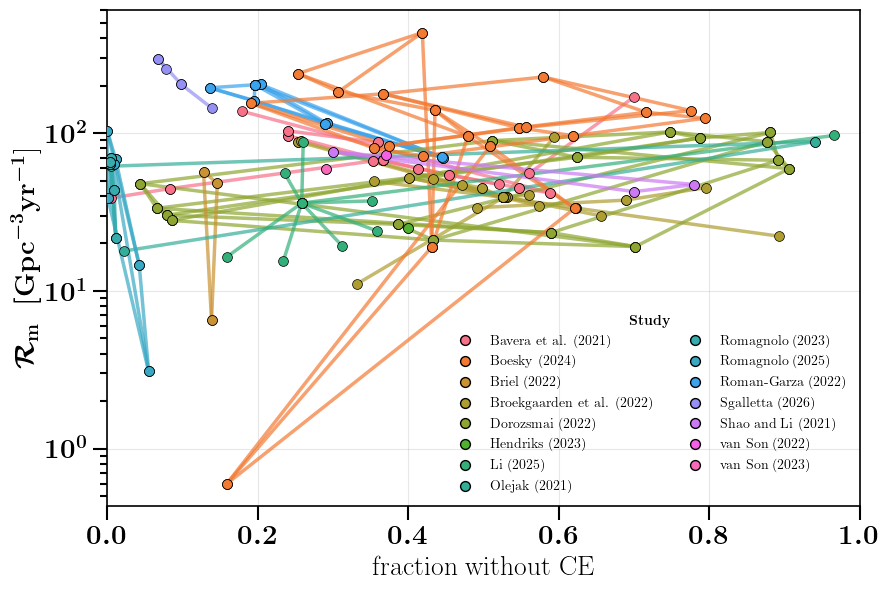

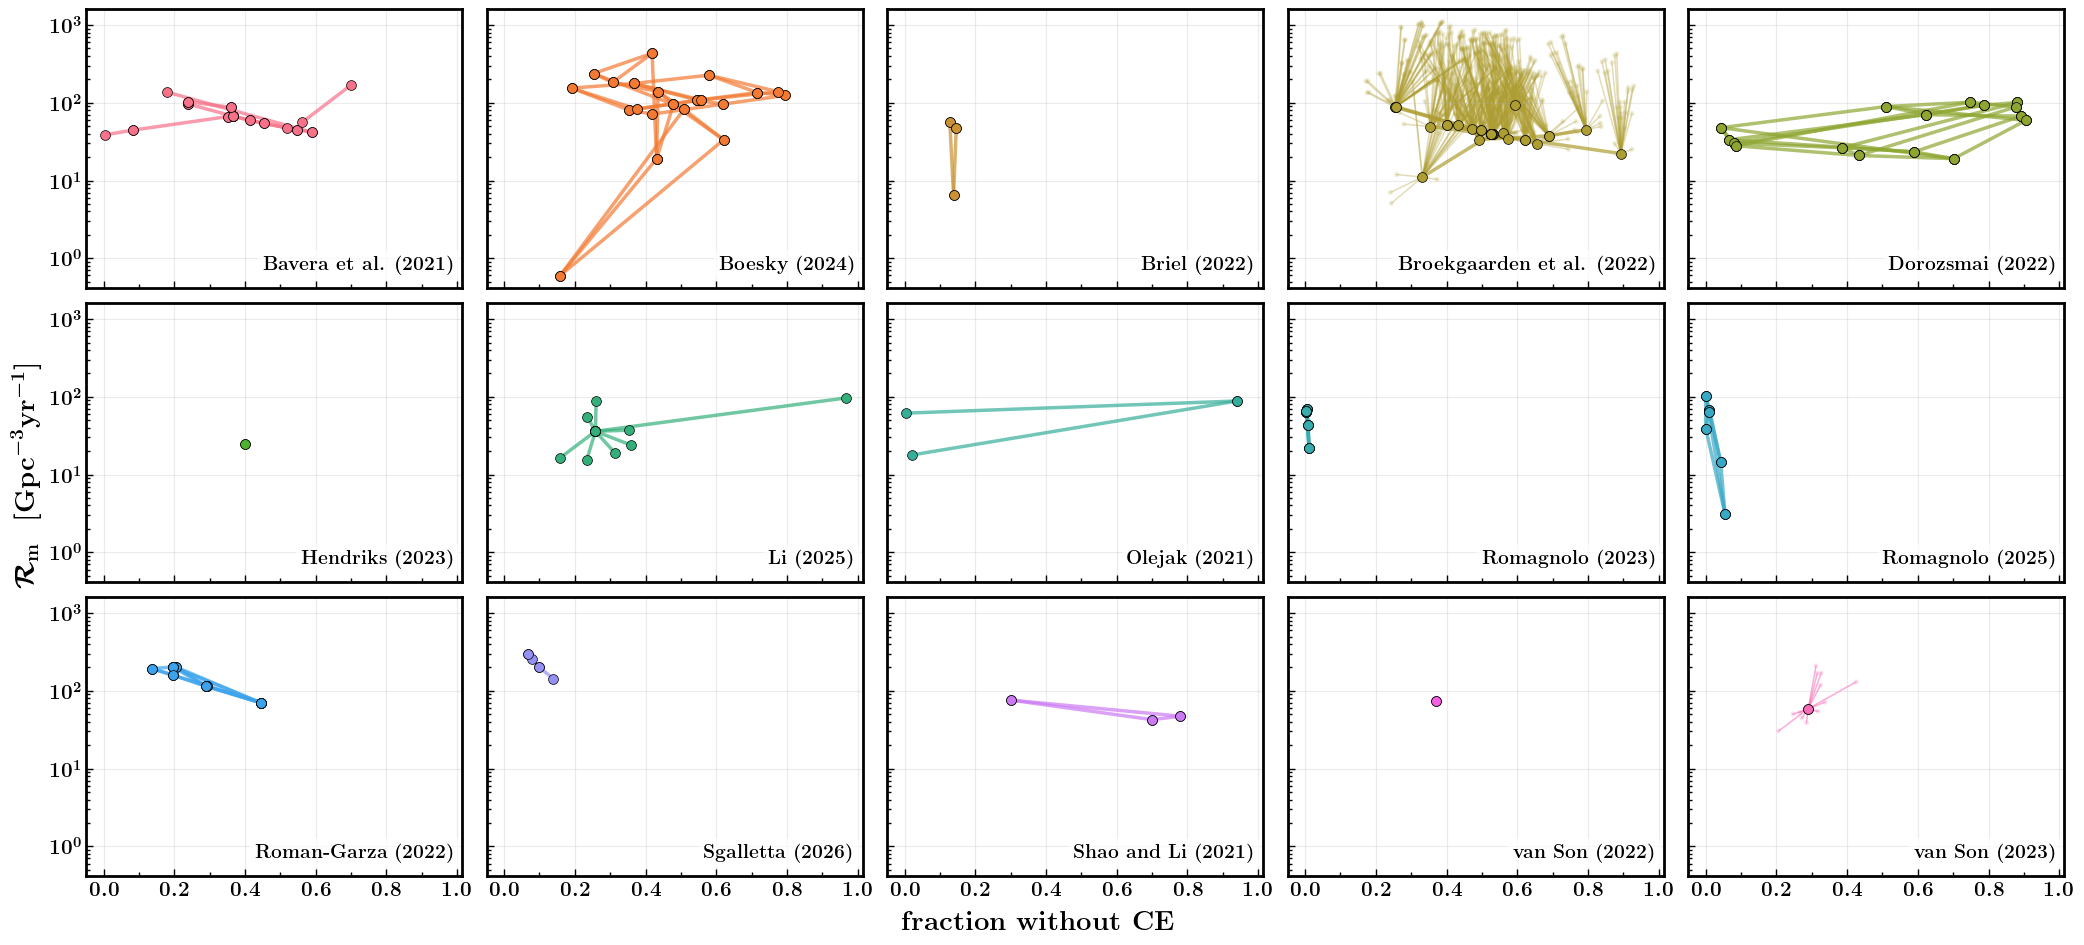


Running for BH-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/fl

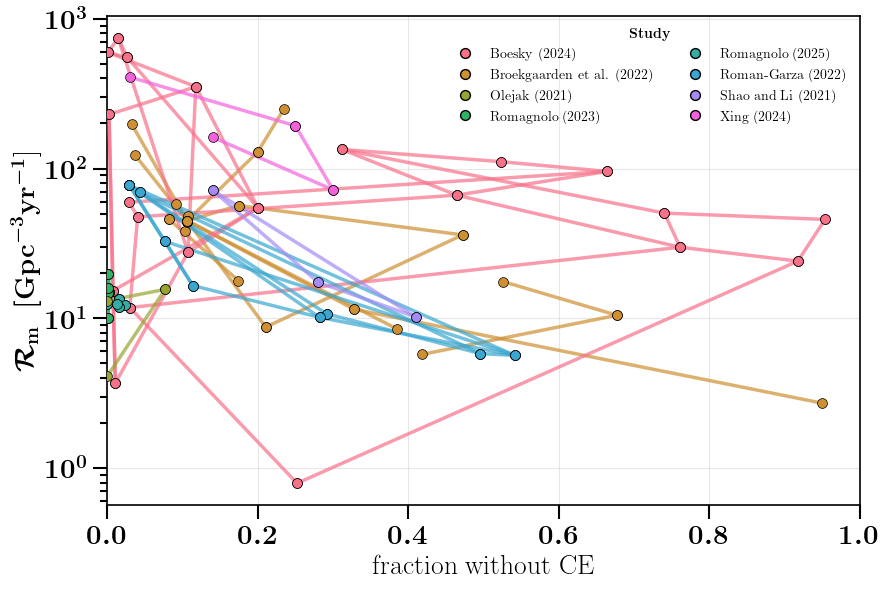

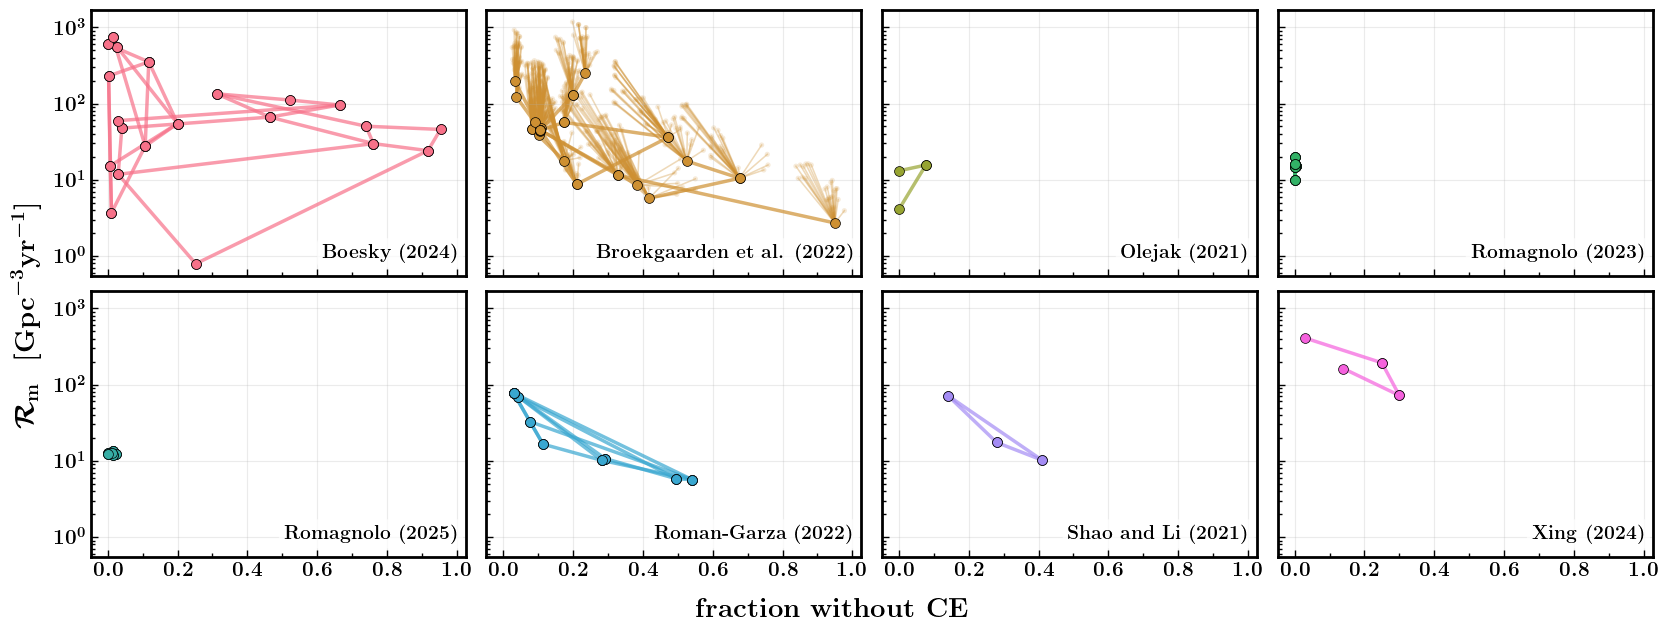


Running for NS-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_NSNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/fl

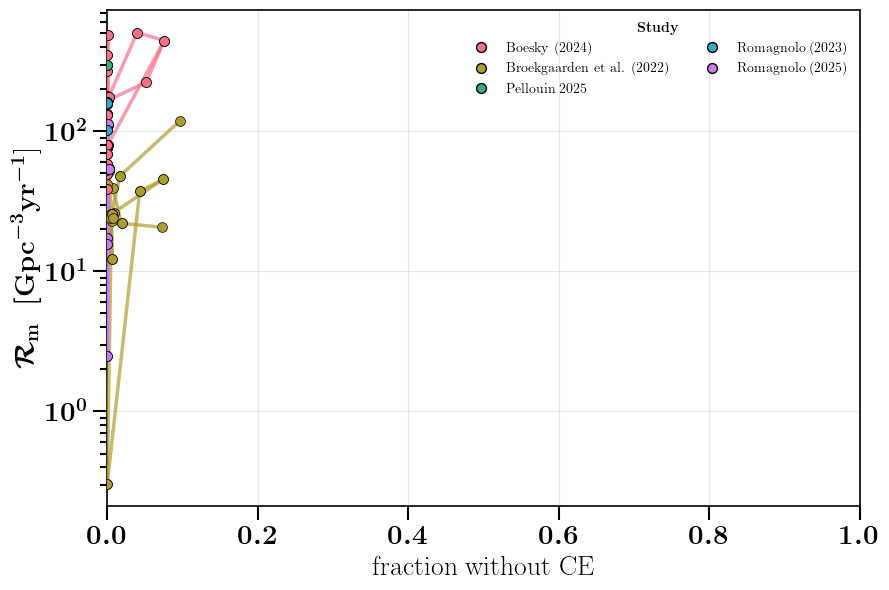

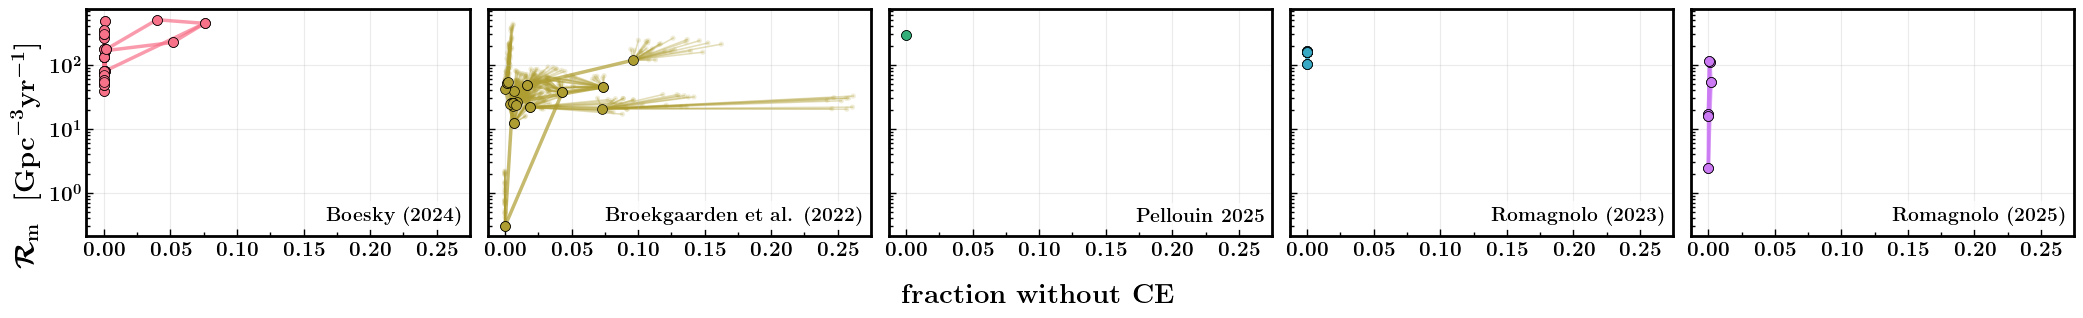

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='fraction without CE', ylabel='$\\mathcal{R}_{\\rm{m}}$ \\  $[\\rm{Gpc}^{-3} \\rm{yr}^{-1}$]'>,
 <Figure size 2100x320 with 5 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

In [4]:
# for dco in ["BH-BH", "BH-NS", "NS-NS"]:
make_withoutCE_plots("BH-BH")
make_withoutCE_plots(DCOlabel="BH-NS", ncols_grid=4)
make_withoutCE_plots(DCOlabel="NS-NS", ncols_grid=5)

# Interactive plots html 



In [5]:
# --- Required imports (add these at the top of your notebook/script) ---
import os
import math
import re
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns

from typing import Optional


def plot_withoutCE_by_study_plotly(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 360,   # pixels per panel (width)
    panel_h: float = 290,   # pixels per panel (height)
    marker_size: int = 9,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",  # seaborn palette
):
    """
    Plotly (non-FigureWidget) version of the *grid by study* plot with:
      - log10 y-axis
      - shared x/y limits across panels
      - hover text on points
      - hover text on lines via invisible midpoint markers (no visual kinks)
      - dropdown toggle by "parameter families" inferred from travel_label
      - HTML export via fig.write_html(...)

    Returns:
      - plotly.graph_objects.Figure
    """

    # ---------- helper: parameter family inferred from travel_label ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()
        if (not s) or (s.lower() == "nan"):
            return "unknown"

        # remove LaTeX $...$ delimiters
        s = s.replace("$", "").strip()

        # remove arrow tokens
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")

        # normalize spaces
        s = re.sub(r"\s+", " ", s).strip()
        return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)
    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    df_rates = df_rates.set_index("model")
    
    
    # ---------- load extra van Son (2023) S(Z,z) variations ----------
    extra_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(extra_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(extra_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None

    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "

    # ---------- infer y-column header via obtain_fc_dict ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = r"Total Merger Rate [Gpc3/yr]" #"[Gpc$^{-3}$ yr$^{-1}$] " # [Gpc$^{-3}$ yr$^{-1}$]" #fc_dict["total"]["axlabel"]

    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    if fc_total_header not in df_rates.columns:
        raise ValueError(
            f"Could not find total-rate column '{fc_total_header}' in rates file. "
            f"Available columns: {list(df_rates.columns)}"
        )
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    # ---------- load simulation specs for point hover labels ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if not os.path.exists(specs_path):
        raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

    df_specs = pd.read_csv(specs_path)
    if "model" not in df_specs.columns:
        raise ValueError("simulation_specs.csv must include a 'model' column.")
    df_specs = df_specs.set_index("model")

    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- global axis limits (shared across all panels) ----------
    xvals = df_rates["fraction without common envelope"].astype(float).values
    yvals = df_rates[fc_total_header].astype(float).values

    # Remove non-positive values for log scale safety
    yvals_pos = yvals[yvals > 0]
    if len(yvals_pos) == 0:
        raise ValueError("All y-values are non-positive; cannot use log axis.")

    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals_pos), np.nanmax(yvals_pos)

    # Add small padding so points are not on edges
    xpad = 0.02 * (xmax - xmin) if xmax > xmin else 0.05
    xmin -= xpad
    xmax += xpad

    # log padding in multiplicative space
    ymin /= 1.2
    ymax *= 1.2

    def point_hover_text(model: str) -> str:
        """Build hover text for a point using label_1..label_4 (only non-empty)."""
        lines = [f"<b>{model}</b>"]
        if model in df_specs.index and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    s = str(v).strip()
                    if s and s.lower() != "nan":
                        vals.append(s)
            if vals:
                lines.append("<br>".join(vals))
        return "<br>".join(lines)

    def line_hover_text(row: pd.Series) -> str:
        tl = str(row.get("travel_label", "")).strip()
        fo = str(row.get("from_option", "")).strip()
        to = str(row.get("to_option", "")).strip()
        return f"change: {tl}: from {fo} to {to}"
    
    
    def add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map):
        """
        Add extra van Son (2023) S(Z,z) variation points/lines to the van Son panel only.
        """
        if df_rates_vanson_sfrd is None:
            return
        if str(leg).strip() != str(vanSon_legend).strip():
            return
        if vanSon_fiducial_model not in df_rates.index:
            return

        x_fid = float(df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"])
        y_fid = float(df_rates.loc[vanSon_fiducial_model, fc_total_header])

        if y_fid <= 0:
            return

        this_color = color_map[leg]

        for model in df_rates_vanson_sfrd.index:
            # skip duplicate fiducial row in extra file, if present
            if "fiducial" in str(model).strip().lower():
                continue

            x = float(df_rates_vanson_sfrd.loc[model, "fraction without common envelope"])
            y = float(df_rates_vanson_sfrd.loc[model, fc_total_header])

            if y <= 0:
                continue

            hover_txt = (
                f"<b>{leg.strip()}</b><br>"
                f"S(Z,z) variation<br>"
                f"{model}<br>"
                f"connected to fiducial"
            )

            # midpoint for hover on log-y axis
            mx = 0.5 * (x_fid + x)
            my = 10 ** (0.5 * (np.log10(y_fid) + np.log10(y)))

            # background line
            fig.add_trace(
                go.Scatter(
                    x=[x_fid, x],
                    y=[y_fid, y],
                    mode="lines",
                    line=dict(width=line_width * 0.9, color=this_color),
                    opacity=0.35,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # visible point
            fig.add_trace(
                go.Scatter(
                    x=[x],
                    y=[y],
                    mode="markers",
                    marker=dict(
                        size=max(6, marker_size - 1),
                        color=this_color,
                        line=dict(width=0.0, color=this_color),
                        opacity=0.75,
                    ),
                    hovertemplate=f"{hover_txt}<extra></extra>",
                    showlegend=False,
                    meta=dict(kind="point", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # invisible hover marker for the connecting line
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

    # ---------- studies + colors ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    n_studies = len(legends_sorted)

    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(palette_name, n_studies)

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

    # ---------- make subplot figure ----------
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=legends_sorted,
        shared_xaxes=True,
        shared_yaxes=True,
        horizontal_spacing=0.02,
        vertical_spacing=0.1,
    )

    # ---------- add traces per study ----------
    for i, leg in enumerate(legends_sorted):
        row_i = i // ncols + 1
        col_i = i % ncols + 1

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # Collect unique models used in this study (for point trace)
        models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
        models = [m for m in models if isinstance(m, str) and m in df_rates.index]

        xs, ys, hovers = [], [], []
        for m in models:
            xs.append(float(df_rates.loc[m, "fraction without common envelope"]))
            ys.append(float(df_rates.loc[m, fc_total_header]))
            hovers.append(point_hover_text(m))

        # Points (one trace per panel)
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_map[leg],
                    line=dict(width=0.8, color="black"),
                    opacity=1.0,
                ),
                hovertemplate="%{text}<extra></extra>",
                text=hovers,
                showlegend=False,
                meta=dict(kind="point", study=str(leg)),
            ),
            row=row_i,
            col=col_i,
        )

        # Lines + invisible hover markers (hover text without FigureWidget callbacks)
        for _, rr in df_sub.iterrows():
            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if not (isinstance(m_from, str) and isinstance(m_to, str)):
                continue
            if m_from not in df_rates.index or m_to not in df_rates.index:
                continue

            x1 = float(df_rates.loc[m_from, "fraction without common envelope"])
            y1 = float(df_rates.loc[m_from, fc_total_header])
            x2 = float(df_rates.loc[m_to, "fraction without common envelope"])
            y2 = float(df_rates.loc[m_to, fc_total_header])

            # skip non-positive y (log safety)
            if y1 <= 0 or y2 <= 0:
                continue

            hover_txt = line_hover_text(rr)
            family = parameter_family_from_travel_label(rr.get("travel_label", ""))

            # Midpoint for log-y axis: geometric mean keeps straightness
            mx = 0.5 * (x1 + x2)
            my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

            # 1) Draw straight line (no hover)
            fig.add_trace(
                go.Scatter(
                    x=[x1, x2],
                    y=[y1, y2],
                    mode="lines",
                    line=dict(width=line_width, color=color_map[leg]),
                    opacity=line_alpha,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # 2) Invisible hover marker at midpoint (drives the hover text)
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )
            
        # Add van Son (2023) extra S(Z,z) variations in the van Son panel
        add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map)

        # Axes per panel
        fig.update_xaxes(type="linear", range=[xmin, xmax], row=row_i, col=col_i)
        fig.update_yaxes(type="log", range=[np.log10(ymin), np.log10(ymax)], row=row_i, col=col_i)

    # Turn off unused panels
    for j in range(n_studies, nrows * ncols):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    # Layout
    fig.update_layout(
        width=int(panel_w * ncols),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=70, r=160, t=70, b=70),
        hovermode="closest",
        hoverdistance=40,
    )

    # Add x-label to every subplot
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            # Skip unused panels
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue

            fig.update_xaxes(
                title_text=f"<b>{xname}</b>",
                row=r,
                col=c
            )
            
    # Add y-label to every subplot
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            # Skip unused panels
            idx = (r - 1) * ncols + (c - 1)
            if c == 1:  # only first column:
                fig.update_yaxes(
                    title_text=yname,
                    row=r,
                    col=c
                )

    # Subplot title styling
    fig.update_annotations(font=dict(size=14))

    # ---------- Dropdown: Toggle parameter families ----------
    families = set()
    for tr in fig.data:
        meta = getattr(tr, "meta", None) or {}
        if meta.get("kind") in ("line", "hover"):
            families.add(meta.get("family", "unknown"))
    families = sorted(families)

    def visibility_for_family(fam: Optional[str]):
        """fam=None shows all; else show only traces for that family. Points always visible."""
        vis = []
        for tr in fig.data:
            meta = getattr(tr, "meta", None) or {}
            kind = meta.get("kind", None)
            if kind == "point" or kind is None:
                vis.append(True)
            elif kind in ("line", "hover"):
                vis.append(True if fam is None else (meta.get("family") == fam))
            else:
                vis.append(True)
        return vis

    buttons = [dict(label="All families", method="update", args=[{"visible": visibility_for_family(None)}])]
    for fam in families:
        buttons.append(dict(label=str(fam), method="update", args=[{"visible": visibility_for_family(fam)}]))

    fig.update_layout(
        updatemenus=[
            dict(
                type="dropdown",
                x=1.02,
                y=1.02,
                xanchor="left",
                yanchor="top",
                buttons=buttons,
            )
        ]
    )

    return fig




# BH-BH 

In [6]:
# ---- Example usage ----
DCOlabel = "BH-BH"

fig = plot_withoutCE_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    DCOlabel="BH-BH",
    ncols_grid=5,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = 'Output_Figures/Fig6_' +  "BH-BH_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: Output_Figures/Fig6_BH-BH_by_study_interactive.html


True

# BH-NS 

In [7]:
# ---- Example usage ----
DCOlabel = "BH-NS"

fig = plot_withoutCE_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    DCOlabel=DCOlabel,
    ncols_grid=4,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = 'Output_Figures/Fig7_' +  DCOlabel + "_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: Output_Figures/Fig7_BH-NS_by_study_interactive.html


True

# NS-NS 

In [8]:
# ---- Example usage ----
DCOlabel = "NS-NS"

fig = plot_withoutCE_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    DCOlabel=DCOlabel,
    ncols_grid=5,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = 'Output_Figures/Fig8_' +  DCOlabel + "_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: Output_Figures/Fig8_NS-NS_by_study_interactive.html


True